In [1]:
import torch
# Hyperparams
p1 = {
    '1_learning_rate': 0.000025, '1_hidden_size': 48, '1_dropout': 0.225,
    '1_quantum' : False, '1_num_head': 4, '1_Attention_N' : 2, '1_num_transf': 2, '1_mlp_size': 5, '1_patch_size': 4, '1_weight_decay': 1e-7, '1_attention_selection': 'none', 
    '1_selection_amount': 49, '1_RD': 1, '1_connectivity' : 'star' ,'1_entangle_method' : 'CRX', '1_special_cls' : 'none', '1_paralel': 1, '1_patience': -1, 
    '1_scheduler_factor': 0.985, '1_q_stride': 1, '1_ancilla' : 0, '1_channels_out' : list(range(4)), '1_augmentation_prob' : 0, '1_val_train_pond' : 1,
    '1_flatten_extra_channels' : False, '1_quanv_kernel_size' : 2
}

p2 = {
    'learning_rate': 0.0025, 'hidden_size': 48, 'dropout': 0.3,
    'quantum' : False, 'num_head': 4, 'Attention_N' : 2, 'num_transf': 2, 'mlp_size': 5, 'patch_size': 4, 'weight_decay': 1e-7, 'attention_selection': 'filter',
    'selection_amount': 49, 'RD': 1, 'special_cls' : 'none', 'paralel': 2, 'patience': -1, 'scheduler_factor': 0.985, 'q_stride': 1, 'augmentation_prob' : 0,
    'val_train_pond' : 1, 'len_channels_scaler' : 2
}

exp_config = {
    'channels_last'         : False,         # True if last dimension of datasets tensors match channels dimension
    'repeat_selector'       : False,         # True to train autoencoder each time for more variability
    'send_telegram'         : True,
    'num_experiments'       : 1,
    'num_classes'           : 7,
    'trained_selector_once' : False,
    'pixels'                : 28,
    'experiment_name'       : 'Resolution224/16x16patches/kernel3x3 Selformer',
    'experiment_id'         : 'final_stand/3x3/dropout_channels/extra_patches/4x4patches/concatenate_original',
    'variant'               : 'selformer',
    'B'                     : 2,
    'special_batch_for_data': False,
    'rewind_channels'       : False,
    'N1'                    : 1,
    'N2'                    : 20,
    'q_config'              : {'patchwise','none'},
    'device'                : torch.device("cuda:1" if torch.cuda.is_available() else "cpu"),
    'second_at_a_time'      : False,
    'augmenting'            : False,
    'concatenate_original'  : True
}

# Helper functions: 
def make_dropout(drop):
    return {'embedding_attn': drop, 'after_attn': drop, 'feedforward': drop, 'embedding_pos': drop}

visualizing_n = 1
concatenate_originals = True

Using downloaded and verified file: /home/carlos/.medmnist/dermamnist.npz
Using downloaded and verified file: /home/carlos/.medmnist/dermamnist.npz
Using downloaded and verified file: /home/carlos/.medmnist/dermamnist.npz
Loaded MedMNIST dataset 'dermamnist' with image size 28x28 and 3 channels.
Using downloaded and verified file: /home/carlos/.medmnist/dermamnist.npz
Started a MutliheadSelfAttention layer with embed_dim: 48 num_heads: 4 head_dim: 12
Started a MutliheadSelfAttention layer with embed_dim: 48 num_heads: 4 head_dim: 12
Number of trainable parameters: 27973


Epoch   1/1: 100%|█████| 3504/3504 [00:13<00:00, 262.18batch/s, Val Loss=1.258, Valid AUC=61.87%, Train AUC=56.46 ||| Valid ACC=66.90%, Train ACC=64.46%]

TOTAL TIME = 13.37s
BEST AUC TRAIN = 56.46% AT EPOCH 1
BEST AUC VAL = 61.87% AT EPOCH 1


TEST AUC: 63.31%, TEST ACC: 66.78%
Shape of object: torch.Size([2, 3, 28, 28])


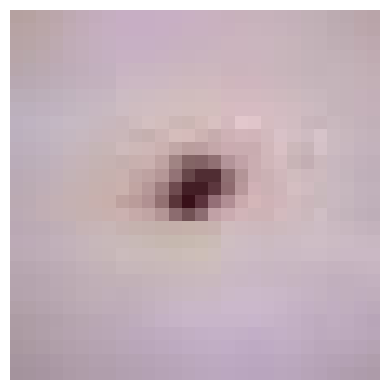

In [2]:
import torch
import mi_quantum.data as data
from mi_quantum.quantum.quanvolution import QuantumConv2D
from mi_quantum.quantum.vit import VisionTransformer
from mi_quantum.training import train_and_evaluate
import matplotlib.pyplot as plt
# Load data
notrans_train_dl, train_dl, val_dl, test_dl, shape = data.get_medmnist_dataloaders(
    pixel = exp_config['pixels'], data_flag='dermamnist', extra_tr_without_trans = True, batch_size=exp_config['B'], num_workers=4, pin_memory=True
)

save_path = "../QTransformer_Results_and_Datasets/selformer_results/current_results/grid_search1"

def view_image_from_torch(tensor, i):
    for j in range(i):
        image_np = tensor[j,...].permute(1, 2, 0).numpy()

        plt.figure(figsize=(15, 4))
        plt.imshow(image_np)
        plt.axis('off')
        plt.tight_layout()
        plt.show()


selector = VisionTransformer(
    img_size=28, num_channels=3, num_classes=exp_config['num_classes'],
    patch_size=p1['1_patch_size'], hidden_size= 3* p1['1_patch_size']**2, num_heads=p1['1_num_head'], Attention_N = p1['1_Attention_N'],
    num_transformer_blocks=p1['1_num_transf'], attention_selection= p1['1_attention_selection'], selection_amount = p1['1_selection_amount'], special_cls = p1['1_special_cls'], 
    mlp_hidden_size=p1['1_mlp_size'], quantum_mlp = False, dropout = make_dropout( p1['1_dropout']) , channels_last=exp_config['channels_last'], quantum_classification = False,
    paralel = p1['1_paralel'], RD = p1['1_RD'], q_stride = p1['1_q_stride'], connectivity = 'chain'
)

selector.to(exp_config['device'])

test_auc_sel, test_acc_sel, val_auc_sel, val_acc_sel, train_auc_sel, _, params_sel = train_and_evaluate(
                        selector, train_dl, val_dl, test_dl, num_classes=exp_config['num_classes'],
                        learning_rate=p1['1_learning_rate'], num_epochs=exp_config['N1'], device=exp_config['device'], mapping=False,
                        res_folder=str(save_path), hidden_size=p1['1_hidden_size'], dropout= make_dropout( p1['1_dropout']),
                        num_heads=p1['1_num_head'], patch_size=p1['1_patch_size'], num_transf=p1['1_num_transf'],
                        mlp=p1['1_mlp_size'], wd=p1['1_weight_decay'], patience= p1['1_patience'], scheduler_factor=p1['1_scheduler_factor'], autoencoder=False,
                        augmentation_prob = p1['1_augmentation_prob'], val_train_pond=p1['1_val_train_pond']
                    )


first_batch = next(iter(notrans_train_dl))[0]

shape = first_batch.shape
B, C, H, W = shape
S, Q2, Q3, P = ( H // p1['1_patch_size'] )**2, 4, 9, p1['1_patch_size']
print(f"Shape of object: {shape}")
view_image_from_torch(first_batch, visualizing_n)


# 2x2 Kernel vs 3x3 Kernel

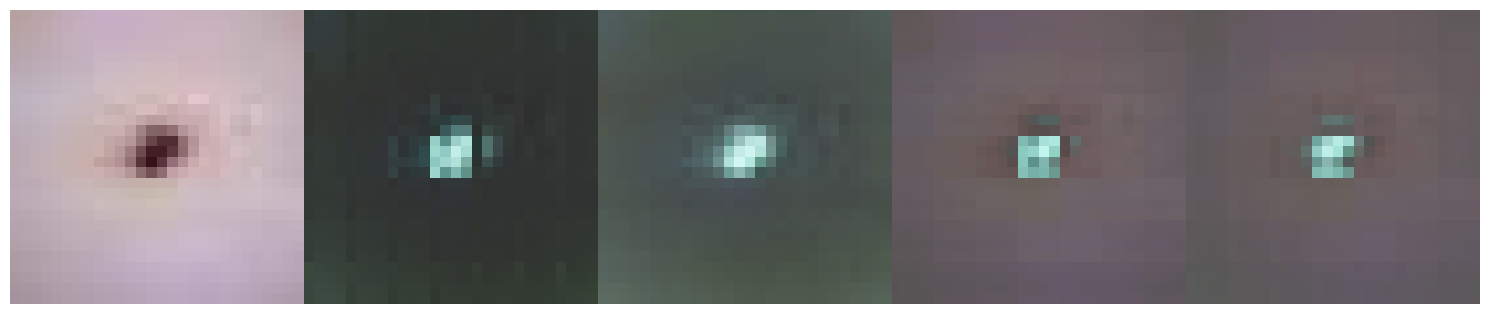

In [3]:
paddings = { 2 : { 'Up': 1, 'Down': 0, 'Left': 1, 'Right': 0 }, 3 : { 'Up': 1, 'Down': 1, 'Left': 1, 'Right': 1 } }

Quanvolution2x2 = QuantumConv2D(kernel_size = 2, stride = 1, padding = paddings[2],
                             channels_out = list(range(4)),ancilla= p1['1_ancilla'],graph = 'star',entangle_method = p1['1_entangle_method']
                            
)

Quanvolution3x3 = QuantumConv2D(kernel_size = 3, stride = 1, padding = paddings[3],
                             channels_out = list(range(9)), ancilla= p1['1_ancilla'], graph = 'king',entangle_method = p1['1_entangle_method']
                            
)
aux_patches, selected_indices = selector.get_patches_by_attention(first_batch.to(exp_config['device']))

Quanvolution2x2.to(exp_config['device'])
Quanvolution3x3.to(exp_config['device'])
aux_patches.to(exp_config['device'])
selected_indices.to(selected_indices)

aux_patches_processed2x2 = Quanvolution2x2(aux_patches.reshape(-1, C, p1['1_patch_size'], p1['1_patch_size'])).reshape(B, p1['1_selection_amount'] * Q2, C * P * P ).to(exp_config['device'])
#aux_patches_processed3x3 = Quanvolution3x3(aux_patches.reshape(-1, C, p1['1_patch_size'], p1['1_patch_size'])).reshape(B, p1['1_selection_amount'] * Q3, C * P * P ).to(exp_config['device'])
if concatenate_originals:
    aux_patches_processed2x2 = torch.cat([aux_patches.reshape(B, p1['1_selection_amount'], C * P * P ), aux_patches_processed2x2 ], dim = 1)
    #aux_patches_processed3x3 = torch.cat([aux_patches.reshape(B, p1['1_selection_amount'], C * P * P ), aux_patches_processed3x3 ], dim = 1)

reconstructed_processed2x2 = selector.reconstruct_image_from_patches(aux_patches_processed2x2, selected_indices, original_image_shape = shape, quantum_channels= Q2, originals = concatenate_originals).squeeze().detach().to('cpu')
#reconstructed_processed3x3 = selector.reconstruct_image_from_patches(aux_patches_processed3x3, selected_indices, original_image_shape = shape, quantum_channels= Q3, originals = concatenate_originals).squeeze().detach().to('cpu')
reconstructed_processed2x2 = reconstructed_processed2x2.permute(0, 2, 3, 1, 4).reshape(B, C, H, (Q2+concatenate_originals)*W)
#reconstructed_processed3x3 = reconstructed_processed3x3.permute(0, 2, 3, 1, 4).reshape(B, C, H, (Q3+concatenate_originals)*W)
view_image_from_torch(reconstructed_processed2x2, visualizing_n)
#view_image_from_torch(reconstructed_processed3x3, visualizing_n)

# Comparison between applying kernel patchwise or imagewise:

In [4]:
processed_first_batch2x2 = Quanvolution2x2(first_batch)
#processed_first_batch3x3 = Quanvolution3x3(first_batch)
if concatenate_originals:
    processed_first_batch2x2 = torch.cat([first_batch, processed_first_batch2x2], dim = 1)
    #processed_first_batch3x3 = torch.cat([first_batch, processed_first_batch3x3], dim = 1)

processed_first_batch2x2 = processed_first_batch2x2.reshape(B, Q2+concatenate_originals, C, H, W).permute(0,2,3,1,4).reshape(B, C, H, (Q2+concatenate_originals)*W)
#processed_first_batch3x3 = processed_first_batch3x3.reshape(B, Q3+concatenate_originals, C, H, W).permute(0,2,3,1,4).reshape(B, C, H, (Q3+concatenate_originals)*W)

# 2x2 Kernel, Imagewise vs Patchwise

Imagewise application of 2x2 kernel


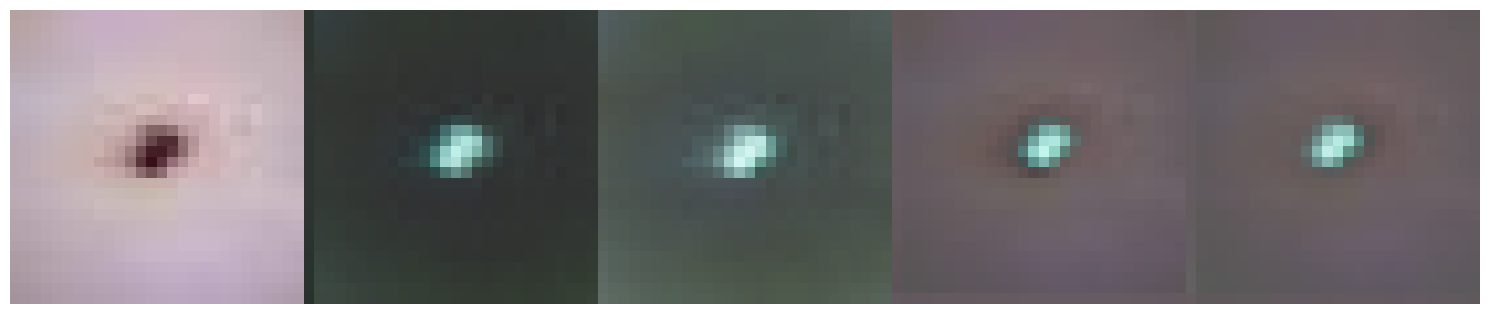

Patchwise application of 2x2 kernel


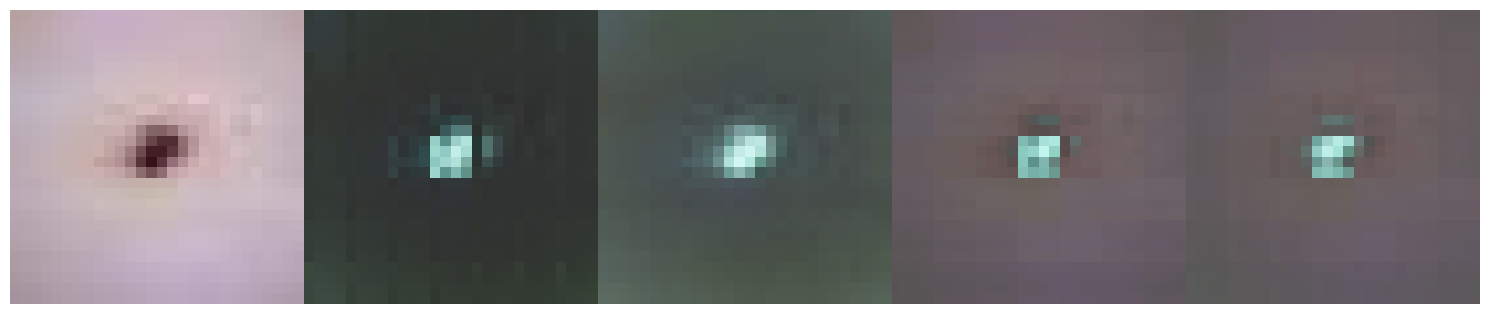

In [5]:
print("Imagewise application of 2x2 kernel")
view_image_from_torch(processed_first_batch2x2, visualizing_n)
print("Patchwise application of 2x2 kernel")
view_image_from_torch(reconstructed_processed2x2, visualizing_n)

# 3x3 Kernel, Imagewise vs Patchwise

Imagewise application of 2x2 kernel


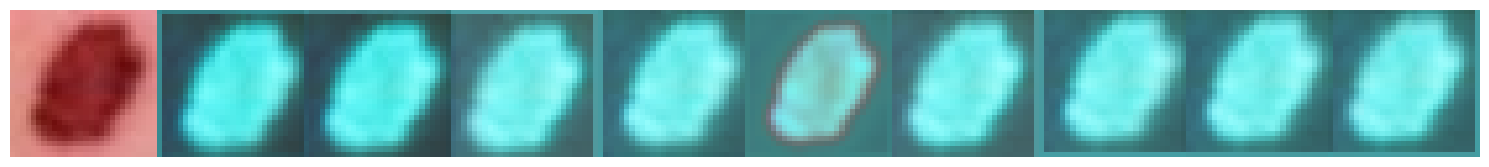

Patchwise application of 3x3 kernel


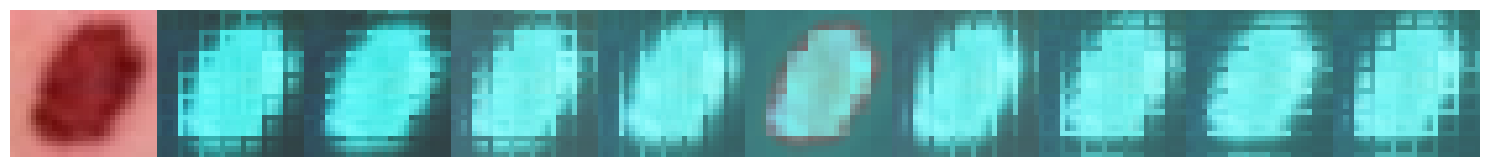

In [7]:
print("Imagewise application of 2x2 kernel")
view_image_from_torch(processed_first_batch3x3, visualizing_n)
print("Patchwise application of 3x3 kernel")
view_image_from_torch(reconstructed_processed3x3, visualizing_n)

# Data pipeline

In [6]:
Kernels = { 
            'patchwise' :   QuantumConv2D(
                                kernel_size = 2,
                                stride = 1,
                                padding = paddings[2],
                                channels_out = list(range(4)),
                                ancilla= p1['1_ancilla'],
                                graph = p1['1_connectivity'],
                                entangle_method = p1['1_entangle_method']
                            )
            }

Latents = data.preprocess_and_save(
    B = exp_config['B'],
    DataLoaders = [notrans_train_dl, val_dl, test_dl],
    kernels = Kernels,
    save_path = f"../QTransformer_Results_and_Datasets/selformer_results/quantum_datasets",
    mode = 'by_selected_patches',
    model1 = selector,
    p1 = p1,
    num_channels = C,
    flatten_extra_channels = p1['1_flatten_extra_channels'],
    device = exp_config['device'],
    flatten = not exp_config['augmenting'], 
    concatenate_original = exp_config.get('concatenate_original', False)
)

latent_train_dl, latent_val_dl, latent_test_dl, shape_latent = Latents['patchwise']

Running in 'by_selected_patches' mode.
Reshape config: Flatten extra channels? False


Processing train split:   0%|          | 1/3504 [00:00<08:06,  7.20it/s]


--- Debug Shapes (q_idx: 0, name: patchwise, split: train, batch 0) ---
Shape out of q-convolution (aux_patch_outs): torch.Size([2, 49, 15, 4, 4])
Shape after reshape (processed_data batch): torch.Size([2, 245, 48])
Stored item shape (last_processed_shapes): torch.Size([245, 48])
--------------------------------------------------


Processing train split: 100%|██████████| 3504/3504 [01:35<00:00, 36.72it/s]


Hypershape for train, kernels patchwise (idx 0): torch.Size([7007, 245, 48]), Labels shape: torch.Size([7007, 1])


Processing validation split: 100%|██████████| 502/502 [00:13<00:00, 37.81it/s]


Hypershape for validation, kernels patchwise (idx 0): torch.Size([1003, 245, 48]), Labels shape: torch.Size([1003, 1])


Processing test split: 100%|██████████| 1003/1003 [00:26<00:00, 37.16it/s]


Hypershape for test, kernels patchwise (idx 0): torch.Size([2005, 245, 48]), Labels shape: torch.Size([2005, 1])
Saved quantum datasets for kernels 'patchwise' at ../QTransformer_Results_and_Datasets/selformer_results/quantum_datasets


In [9]:
classifier = VisionTransformer(
                                    img_size=shape[-1], num_channels= 3, num_classes=exp_config['num_classes'],
                                    patch_size=p2['patch_size'], hidden_size= shape_latent[-1], num_heads=p2['num_head'], Attention_N = p2['Attention_N'],
                                    num_transformer_blocks=p2['num_transf'], attention_selection= p2['attention_selection'], special_cls = p2['special_cls'], 
                                    mlp_hidden_size=p2['mlp_size'], quantum_mlp = False, dropout = make_dropout(p2['dropout']), channels_last=exp_config['channels_last'], quantum_classification = False,
                                    paralel = p2['paralel'] , RD = p2['RD'], q_stride = p2['q_stride'], connectivity = 'chain', patch_embedding_required = 'flatten' if exp_config['augmenting'] else 'false'
                                )


# Train second model
test_auc, test_acc, val_auc, val_acc, train_auc, train_acc, params = train_and_evaluate(
    classifier, latent_train_dl, latent_val_dl, latent_test_dl, num_classes=exp_config['num_classes'],
    learning_rate=p2['learning_rate'], num_epochs=exp_config['N2'], device=exp_config['device'], mapping=False,
    res_folder=str(save_path), hidden_size=p2['hidden_size'], dropout=make_dropout(p2['dropout']),
    num_heads=p2['num_head'], patch_size=p2['patch_size'], num_transf=p2['num_transf'],
    mlp=p2['mlp_size'], wd=p2['weight_decay'], patience= p2['patience'], scheduler_factor=p2['scheduler_factor'], 
    autoencoder=False, augmentation_prob = p2['augmentation_prob'], val_train_pond=p2['val_train_pond']
)

Started a MutliheadSelfAttention layer with embed_dim: 48 num_heads: 4 head_dim: 12
Started a MutliheadSelfAttention layer with embed_dim: 48 num_heads: 4 head_dim: 12
Started a MutliheadSelfAttention layer with embed_dim: 48 num_heads: 4 head_dim: 12
Started a MutliheadSelfAttention layer with embed_dim: 48 num_heads: 4 head_dim: 12
Number of trainable parameters: 43931


Epoch  20/20: 100%|█████| 3504/3504 [00:33<00:00, 105.05batch/s, Val Loss=0.790, Valid AUC=88.34%, Train AUC=86.70 ||| Valid ACC=70.59%, Train ACC=69.72%]


TOTAL TIME = 654.25s
BEST AUC TRAIN = 86.70% AT EPOCH 20
BEST AUC VAL = 88.34% AT EPOCH 20
TEST AUC: 87.29%, TEST ACC: 70.17%


In [12]:
def rank_patches_by_attention(attn: torch.Tensor) -> torch.Tensor:
            """
            Ranks image patches by the total attention they receive.

            """
            # Average over heads: (B, T, T)
            attn_mean = attn.mean(dim=1)

            # Total attention received by each token: sum over the source positions (axis=-2)
            # attention_received[b, j] = sum over i of attn[b, i, j]
            attention_received = attn_mean.sum(dim=1)  # shape: (B, T)

            # Sort patches by total attention received, descending
            sorted_indices = attention_received.argsort(dim=1, descending=True)  # shape: (B, T)

            return sorted_indices

for i, dl in enumerate([latent_train_dl, latent_val_dl, latent_test_dl]):

    quantum_percentage = []
    first = True
     
    for imgs, labels, idxs in dl:
        _ , attention_for_images = classifier.transformer_blocks[0][0].attn(imgs.to(exp_config['device']))
        indices_by_attention = rank_patches_by_attention(attention_for_images)
        mask = (indices_by_attention >= p1['1_selection_amount'])
        quantum_percentage.append( torch.sum(  mask ) / ( p1['1_selection_amount'] * (1+len(p1['1_channels_out'])) * imgs.shape[0]))

    print(f"Split {i} has an average selection of quantum patches of {sum(quantum_percentage)/len(quantum_percentage)}")

Split 0 has an average selection of quantum patches of 0.8000277280807495
Split 1 has an average selection of quantum patches of 0.7999969124794006
Split 2 has an average selection of quantum patches of 0.7999923825263977
